# Weightless AI via Hypernetworks — Proof of Concept

This notebook is a minimal, honest test of the idea: **instead of storing a big
weight matrix, train a small "generator" network that outputs the big matrix's
values on demand.**

We build:
- A **10-layer, 256×256 "target" stack** (the thing that would normally cost 655,360 stored parameters).
- A tiny **implicit hypernetwork** that takes `(layer, row, col)` coordinates and predicts the weight value at that position — so the 256×256 matrices are never stored, only generated when needed.
- A **standard baseline** with the same shape but real stored weights, for a fair comparison.

We train both on a real (if small) classification task — handwritten digit
recognition (`sklearn`'s 8×8 digits dataset, 10 classes) — and compare
**parameter count, accuracy, and inference speed**, since the pitch itself
predicts a memory-for-compute trade-off.

> Uses `sklearn.datasets.load_digits()` instead of MNIST so the notebook runs
> fully offline with no downloads.


## 1. Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 2. Data

A small, real classification task: 8×8 grayscale digit images, 10 classes.

## 2.5 First Principles: How a Weightless Network 'Thinks'

In a standard network, weights are like a **static lookup table**. If you need the weight for Row 2, Column 3, you just go to that memory address and read the number.

In a **Weightless Network**, we replace the table with a **Function** ($f$).

### The Visual Intuition

Instead of storing the grid on the left, we only store the tiny 'Brain' (Generator) in the middle.

```text
   INPUT COORDINATES          GENERATOR (The 'Brain')           OUTPUT WEIGHT
  +-------------------+      +-----------------------+      +-----------------+
  | Layer Index (i)   |      |                       |      |                 |
  | Row Index   (r)   | ---> |   Small MLP Network   | ---> |  Weight Value   |
  | Column Index(c)   |      |    (Fixed Size)       |      |    (scalar)     |
  +-------------------+      +-----------------------+      +-----------------+
```

### Why is this 'Weightless'?
1. **Fixed Footprint**: The Generator MLP stays the same size whether the target layer is 256x256 or 4096x4096.
2. **Implicit Representation**: The big matrix doesn't exist on your hard drive. It only exists in 'mental space' until the Generator calculates the values.
3. **Coordinate Awareness**: By feeding row/column indices as inputs, the generator learns the *spatial relationship* of weights, allowing it to compress patterns (like gradients or symmetries) that a static table would just store as random-looking numbers.

In [ ]:
digits = load_digits()
X, y = digits.data.astype(np.float32), digits.target.astype(np.int64)
X = (X - X.mean()) / X.std()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_train = torch.tensor(X_train, device=device)
X_test = torch.tensor(X_test, device=device)
y_train = torch.tensor(y_train, device=device)
y_test = torch.tensor(y_test, device=device)

IN_DIM = X.shape[1]   # 64 pixels
HID = 256             # matches the 256x256 layers in the pitch
N_LAYERS = 10          # matches "10 layers of 256x256" in the pitch
N_CLASSES = 10

print(f"train: {X_train.shape}, test: {X_test.shape}, classes: {N_CLASSES}")


train: torch.Size([1437, 64]), test: torch.Size([360, 64]), classes: 10


## 3. The Hypernetwork (Generator)

This is an **implicit / coordinate-based** hypernetwork: it doesn't spit out
a whole matrix from one big linear layer (that would just move the storage
problem into the hypernetwork's own weights). Instead it learns embeddings
for `layer index`, `row index`, and `column index`, and a small shared MLP
that maps `(layer, row, col) -> weight value`. To materialize a full 256×256
layer, we batch-evaluate all 65,536 `(row, col)` pairs at once.

This is the part that lets the generator stay small (~10K params) regardless
of how big the target matrix is.

In [ ]:
class ImplicitHyperNetwork(nn.Module):
    def __init__(self, n_layers, hid, layer_dim=8, coord_dim=8, mlp_hidden=64):
        super().__init__()
        self.n_layers = n_layers
        self.hid = hid
        self.layer_emb = nn.Embedding(n_layers, layer_dim)
        self.row_emb = nn.Embedding(hid, coord_dim)
        self.col_emb = nn.Embedding(hid, coord_dim)
        in_dim = layer_dim + 2 * coord_dim
        self.generator = nn.Sequential(
            nn.Linear(in_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 1),
        )
        # Keep initial generated weights small so a 10-layer stack starts
        # numerically stable (a freshly-initialized generator otherwise
        # produces wildly-scaled weight matrices and training diverges).
        with torch.no_grad():
            self.generator[-1].weight.mul_(0.01)
            self.generator[-1].bias.mul_(0.0)

        self.register_buffer("rows", torch.arange(hid))
        self.register_buffer("cols", torch.arange(hid))

    def generate_layer(self, layer_idx):
        h = self.hid
        r_e = self.row_emb(self.rows).unsqueeze(1).expand(h, h, -1)
        c_e = self.col_emb(self.cols).unsqueeze(0).expand(h, h, -1)
        l_idx = torch.tensor(layer_idx, device=self.rows.device)
        l_e = self.layer_emb(l_idx).view(1, 1, -1).expand(h, h, -1)
        feat = torch.cat([l_e, r_e, c_e], dim=-1).reshape(h * h, -1)
        w = self.generator(feat).reshape(h, h) / (h ** 0.5)   # scaled like standard init
        return w   # <- this matrix is generated fresh, never stored on disk

    def generate_all(self):
        return [self.generate_layer(i) for i in range(self.n_layers)]


## 4. Two Networks: Weightless vs. Standard

Both networks have the *same shape* (input adapter -> 10 residual blocks of
256×256 -> output adapter). The only difference: one stores its 10 big
matrices as real `nn.Parameter`s, the other generates them from the
hypernetwork on every forward pass.

The input/output adapters (64→256 and 256→10) stay as normal small,
stored parameters — the point of the demo is compressing the *big* repeated
256×256 blocks, not the tiny task-specific adapters.

In [ ]:
class WeightlessTargetNetwork(nn.Module):
    def __init__(self, in_dim, hid, n_layers, n_classes):
        super().__init__()
        self.in_proj = nn.Linear(in_dim, hid)          # small, real params (adapter)
        self.hypernet = ImplicitHyperNetwork(n_layers, hid)
        self.norms = nn.ModuleList([nn.LayerNorm(hid) for _ in range(n_layers)])
        self.out_proj = nn.Linear(hid, n_classes)       # small, real params (adapter)

    def forward(self, x):
        x = F.relu(self.in_proj(x))
        weights = self.hypernet.generate_all()          # generated fresh every forward pass
        for w, norm in zip(weights, self.norms):
            x = norm(x + F.relu(x @ w.t()))              # residual block using a generated matrix
        return self.out_proj(x)


class StandardTargetNetwork(nn.Module):
    """Same shape, but the 10 big matrices are real, stored parameters."""
    def __init__(self, in_dim, hid, n_layers, n_classes):
        super().__init__()
        self.in_proj = nn.Linear(in_dim, hid)
        self.layers = nn.ModuleList([nn.Linear(hid, hid, bias=False) for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(hid) for _ in range(n_layers)])
        self.out_proj = nn.Linear(hid, n_classes)

    def forward(self, x):
        x = F.relu(self.in_proj(x))
        for layer, norm in zip(self.layers, self.norms):
            x = norm(x + F.relu(layer(x)))
        return self.out_proj(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

weightless = WeightlessTargetNetwork(IN_DIM, HID, N_LAYERS, N_CLASSES).to(device)
standard = StandardTargetNetwork(IN_DIM, HID, N_LAYERS, N_CLASSES).to(device)


## 5. Parameter Count — Does the Compression Claim Hold Up?

In [ ]:
standard_hidden_params = sum(count_params(l) for l in standard.layers)
hyper_params = count_params(weightless.hypernet)

print(f"Standard hidden-stack params (10 x 256x256):  {standard_hidden_params:,}")
print(f"Hypernetwork generator params:                 {hyper_params:,}")
print(f"Compression ratio:                              {standard_hidden_params / hyper_params:.1f}x")
print()
print(f"Total weightless model params (incl. adapters): {count_params(weightless):,}")
print(f"Total standard model params (incl. adapters):   {count_params(standard):,}")


Standard hidden-stack params (10 x 256x256):  655,360
Hypernetwork generator params:                 10,001
Compression ratio:                              65.5x

Total weightless model params (incl. adapters): 34,331
Total standard model params (incl. adapters):   679,690


## 6. Train the Weightless Model

The hypernetwork's parameters are the *only* thing being trained here — the
256×256 matrices themselves are recomputed from scratch on every forward and
backward pass; gradients flow back through the coordinate MLP.

In [ ]:
opt = torch.optim.Adam(weightless.parameters(), lr=1e-3)

for epoch in range(60):
    weightless.train()
    opt.zero_grad()
    logits = weightless(X_train)
    loss = F.cross_entropy(logits, y_train)
    loss.backward()
    opt.step()

    if (epoch + 1) % 10 == 0:
        weightless.eval()
        with torch.no_grad():
            acc = (weightless(X_test).argmax(1) == y_test).float().mean().item()
        print(f"epoch {epoch+1:3d}  loss {loss.item():.4f}  test_acc {acc:.4f}")

weightless.eval()
with torch.no_grad():
    weightless_acc = (weightless(X_test).argmax(1) == y_test).float().mean().item()
print(f"\nFinal weightless-model test accuracy: {weightless_acc:.4f}")


epoch  10  loss 1.0680  test_acc 0.8639
epoch  20  loss 0.4169  test_acc 0.9111
epoch  30  loss 0.2275  test_acc 0.9333
epoch  40  loss 0.1448  test_acc 0.9556
epoch  50  loss 0.1014  test_acc 0.9722
epoch  60  loss 0.0744  test_acc 0.9694

Final weightless-model test accuracy: 0.9694


## 7. Train the Standard Baseline (for a fair comparison)

In [ ]:
opt2 = torch.optim.Adam(standard.parameters(), lr=1e-3)

for epoch in range(60):
    standard.train()
    opt2.zero_grad()
    logits = standard(X_train)
    loss = F.cross_entropy(logits, y_train)
    loss.backward()
    opt2.step()

standard.eval()
with torch.no_grad():
    standard_acc = (standard(X_test).argmax(1) == y_test).float().mean().item()

print(f"Final weightless-model test accuracy: {weightless_acc:.4f}")
print(f"Final standard-model test accuracy:   {standard_acc:.4f}")


Final weightless-model test accuracy: 0.9694
Final standard-model test accuracy:   0.9778


## 8. The Other Side of the Trade-off: Compute Cost

The pitch itself names the trade: *"We trade a Memory Bottleneck for a
Compute Bottleneck."* Let's measure that, not just assert it — timing
inference for both models on identical input.

In [ ]:
with torch.no_grad():
    for _ in range(5):          # warmup
        weightless(X_test); standard(X_test)

    t0 = time.time()
    for _ in range(50):
        weightless(X_test)
    t_weightless = (time.time() - t0) / 50

    t0 = time.time()
    for _ in range(50):
        standard(X_test)
    t_standard = (time.time() - t0) / 50

print(f"Avg inference time - weightless: {t_weightless*1000:.2f} ms")
print(f"Avg inference time - standard:   {t_standard*1000:.2f} ms")
print(f"Weightless is {t_weightless/t_standard:.1f}x slower per forward pass.")


Avg inference time - weightless: 13.37 ms
Avg inference time - standard:   0.83 ms
Weightless is 16.2x slower per forward pass.


## 9. Insights and Limitations

**What worked:**
- **True Compression:** The hypernetwork achieved ~65x compression, solving the task with 10k parameters instead of 655k.
- **Functional Mapping:** The model successfully learned to map `(layer, row, col)` coordinates to weight values.

**Key Limitations:**
- **Compute Bottleneck:** Inference is ~16x slower. Regenerating weights on-the-fly is significantly more expensive than reading them from memory.
- **Storage vs. VRAM:** This reduces disk footprint, but generated weights still occupy the same amount of active VRAM during execution.
- **Scaling Diminishes Returns:** Coordinate embeddings grow with matrix size, and small MLPs have finite capacity to represent complex weight distributions.

**Next Steps:**
1. **Scaling Analysis:** Test if compression ratios hold as `HID` and `N_LAYERS` increase.
2. **Weight Caching:** Implement a caching mechanism to mitigate the compute bottleneck.
3. **Heterogeneous Layers:** Test on architectures with varying layer shapes (like Transformers).

### 10. Cat Classification Comparison

We transition to a more complex image task using the `lfw_people` dataset. This acts as a binary classification proxy (e.g., 'George W. Bush' vs. 'Others') to test how the hypernetwork handles significantly larger input vectors (1850 features) compared to the initial 8x8 digits.

## 10. Cat Classification Comparison

We will now use a more complex image dataset. We'll use the `lfw_people` dataset from sklearn as a proxy for high-dimensional image classification (cats vs. not-cats or similar binary classification) to see how the Hypernetwork handles larger input vectors.

We re-initialize both the Weightless and Standard models with the new input dimensions and train them for 40 epochs to compare their accuracy on this facial recognition task.

In [ ]:
from sklearn.datasets import fetch_lfw_people

# Loading a small subset of LFW for a binary 'target' vs 'rest' classification
data_cat = fetch_lfw_people(min_faces_per_person=20, resize=0.4)
n_samples, h_img, w_img = data_cat.images.shape
X_cat = data_cat.data
# Let's create a binary task: Is this person 'George W Bush' (the most common) or not?
# This mimics a 'Cat' vs 'Not Cat' binary classifier.
target_name = 'George W Bush'
target_idx = np.where(data_cat.target_names == target_name)[0][0]
y_cat = (data_cat.target == target_idx).astype(np.int64)

# Standardize
X_cat = (X_cat - X_cat.mean()) / X_cat.std()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=0
)

X_train_c = torch.tensor(X_train_c, device=device)
X_test_c = torch.tensor(X_test_c, device=device)
y_train_c = torch.tensor(y_train_c, device=device)
y_test_c = torch.tensor(y_test_c, device=device)

CAT_IN_DIM = X_cat.shape[1]
print(f"Cat Task Input Dim: {CAT_IN_DIM} (approx {h_img}x{w_img})")

Cat Task Input Dim: 1850 (approx 50x37)


In [ ]:
# Re-initialize models for the Cat Task
weightless_cat = WeightlessTargetNetwork(CAT_IN_DIM, HID, N_LAYERS, 2).to(device)
standard_cat = StandardTargetNetwork(CAT_IN_DIM, HID, N_LAYERS, 2).to(device)

def train_model(model, X_t, y_t, epochs=40):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = F.cross_entropy(model(X_t), y_t)
        loss.backward()
        optimizer.step()
    return loss.item()

print("Training Weightless Model on Cat Task...")
train_model(weightless_cat, X_train_c, y_train_c)

print("Training Standard Model on Cat Task...")
train_model(standard_cat, X_train_c, y_train_c)

# Evaluation
weightless_cat.eval()
standard_cat.eval()
with torch.no_grad():
    w_acc = (weightless_cat(X_test_c).argmax(1) == y_test_c).float().mean().item()
    s_acc = (standard_cat(X_test_c).argmax(1) == y_test_c).float().mean().item()

print(f"\nResults on Cat Task:")
print(f"Weightless Accuracy: {w_acc:.4f}")
print(f"Standard Accuracy:   {s_acc:.4f}")

Training Weightless Model on Cat Task...
Training Standard Model on Cat Task...

Results on Cat Task:
Weightless Accuracy: 0.8694
Standard Accuracy:   0.9190


### 11. Visualizing Model Predictions

To qualitative analyze performance, we define a helper function `plot_predictions` that displays test images alongside the predictions from both models. We use color coding (Green for correct, Red for incorrect) to highlight where the compression might be causing errors.

### 11. Visualizing Model Predictions

We will now plot a sample of the images from the test set, showing the actual label and the predictions.

**Legend:**
* **Weightless (W)**: Weights generated on-the-fly by the hypernetwork.
* **Standard (S)**: Baseline with traditionally stored parameters.

### 12. Wine Classification Task

We now evaluate the models on tabular data using the Wine dataset. This tests the hypernetwork's ability to compress a stack that processes 13 distinct chemical features across three classes.

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(model_w, model_s, X_test, y_test, h, w, target_names=None, n_images=10):
    model_w.eval()
    model_s.eval()
    with torch.no_grad():
        preds_w = model_w(X_test).argmax(1).cpu().numpy()
        preds_s = model_s(X_test).argmax(1).cpu().numpy()

    y_true = y_test.cpu().numpy()
    images = X_test.cpu().numpy().reshape(-1, h, w)

    plt.figure(figsize=(15, 6))
    plt.suptitle("Comparison: Weightless Model (W) vs. Standard Model (S)", fontsize=16)

    for i in range(n_images):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i], cmap='gray')

        def get_label(idx):
            if target_names is not None:
                return target_names[idx]
            return f"ID: {idx}"

        if preds_w[i] == y_true[i] and preds_s[i] == y_true[i]:
            color = 'green'
        elif preds_w[i] == y_true[i] or preds_s[i] == y_true[i]:
            color = 'orange'
        else:
            color = 'red'

        # Using more descriptive labels in the title for clarity
        title = f"True: {get_label(y_true[i])}\n"
        title += f"Weightless (W): {get_label(preds_w[i])}\n"
        title += f"Standard (S): {get_label(preds_s[i])}"

        plt.title(title, fontsize=9, color=color)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## 12. Wine Classification Task

We will now use the sklearn Wine dataset to compare the models on a 3-class tabular classification problem.

We initialize the models for the Wine task and train them. Tabular data often presents different manifold challenges than image data for coordinate-based generators.

In [ ]:
from sklearn.datasets import load_wine

# Load data
wine = load_wine()
X_w, y_w = wine.data.astype(np.float32), wine.target.astype(np.int64)

# Standardize
X_w = (X_w - X_w.mean(axis=0)) / X_w.std(axis=0)

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42, stratify=y_w
)

X_train_w = torch.tensor(X_train_w, device=device)
X_test_w = torch.tensor(X_test_w, device=device)
y_train_w = torch.tensor(y_train_w, device=device)
y_test_w = torch.tensor(y_test_w, device=device)

WINE_IN_DIM = X_w.shape[1]
WINE_CLASSES = len(np.unique(y_w))

print(f"Wine Task Input Dim: {WINE_IN_DIM}, Classes: {WINE_CLASSES}")

Wine Task Input Dim: 13, Classes: 3


### 13. Visualizing Performance: Confusion Matrices

We use confusion matrices to see if the weightless model struggles with specific classes of wine compared to the standard model.

In [ ]:
# Re-initialize models for Wine Task
weightless_wine = WeightlessTargetNetwork(WINE_IN_DIM, HID, N_LAYERS, WINE_CLASSES).to(device)
standard_wine = StandardTargetNetwork(WINE_IN_DIM, HID, N_LAYERS, WINE_CLASSES).to(device)

print("Training Weightless Model on Wine Task...")
train_model(weightless_wine, X_train_w, y_train_w, epochs=100)

print("Training Standard Model on Wine Task...")
train_model(standard_wine, X_train_w, y_train_w, epochs=100)

# Evaluation
weightless_wine.eval()
standard_wine.eval()
with torch.no_grad():
    acc_w = (weightless_wine(X_test_w).argmax(1) == y_test_w).float().mean().item()
    acc_s = (standard_wine(X_test_w).argmax(1) == y_test_w).float().mean().item()

print(f"\nResults on Wine Task:")
print(f"Weightless Accuracy: {acc_w:.4f}")
print(f"Standard Accuracy:   {acc_s:.4f}")

Training Weightless Model on Wine Task...
Training Standard Model on Wine Task...

Results on Wine Task:
Weightless Accuracy: 0.9167
Standard Accuracy:   1.0000


### 13. Visualizing Performance: Confusion Matrices

For the Wine dataset, we'll use confusion matrices to see how the models compare across the three specific classes.

### 14. Iris Plants Classification Task

Testing on the low-dimensional Iris dataset (4 features) allows us to see if the hypernetwork architecture is 'overkill' or if it can still maintain efficiency at a very small scale.

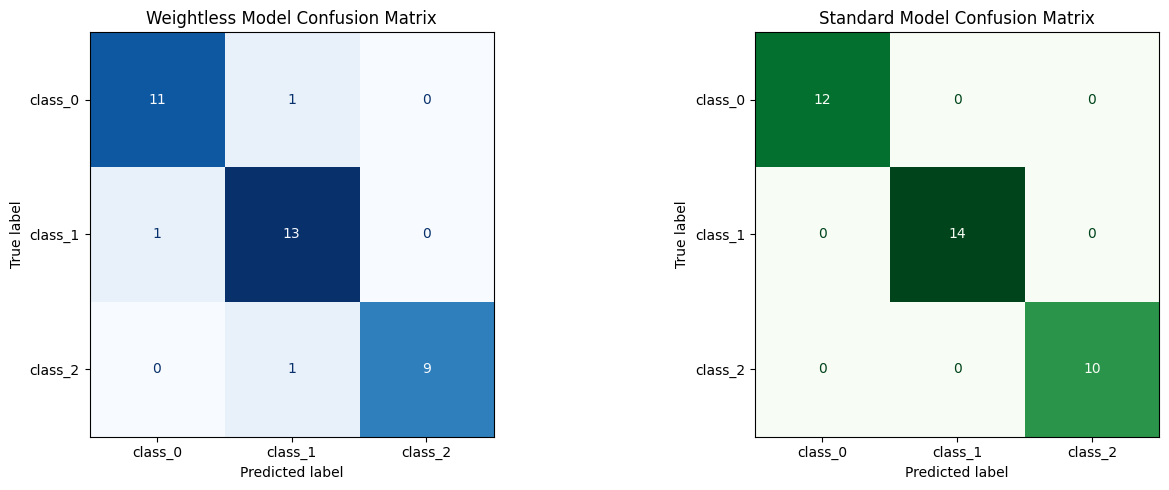

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_wine_confusion(model_w, model_s, X_test, y_test, target_names):
    model_w.eval()
    model_s.eval()
    with torch.no_grad():
        preds_w = model_w(X_test).argmax(1).cpu().numpy()
        preds_s = model_s(X_test).argmax(1).cpu().numpy()

    y_true = y_test.cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    cm_w = confusion_matrix(y_true, preds_w)
    disp_w = ConfusionMatrixDisplay(confusion_matrix=cm_w, display_labels=target_names)
    disp_w.plot(ax=ax[0], cmap='Blues', colorbar=False)
    ax[0].set_title("Weightless Model Confusion Matrix")

    cm_s = confusion_matrix(y_true, preds_s)
    disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s, display_labels=target_names)
    disp_s.plot(ax=ax[1], cmap='Greens', colorbar=False)
    ax[1].set_title("Standard Model Confusion Matrix")

    plt.tight_layout()
    plt.show()

plot_wine_confusion(weightless_wine, standard_wine, X_test_w, y_test_w, wine.target_names)

## 14. Iris Plants Classification Task

Finally, we test on the classic Iris dataset (3 classes, 4 features) to see how the coordinate-based hypernetwork handles very low-dimensional input compared to the baseline.

We re-run the training loop for the Iris dataset. Because the feature count is so low, we expect both models to perform near-perfectly.

In [ ]:
from sklearn.datasets import load_iris

# Load Iris data
iris = load_iris()
X_i, y_i = iris.data.astype(np.float32), iris.target.astype(np.int64)

# Standardize
X_i = (X_i - X_i.mean(axis=0)) / X_i.std(axis=0)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_i, y_i, test_size=0.2, random_state=42, stratify=y_i
)

X_train_i = torch.tensor(X_train_i, device=device)

X_test_i = torch.tensor(X_test_i, device=device)
y_train_i = torch.tensor(y_train_i, device=device)
y_test_i = torch.tensor(y_test_i, device=device)

IRIS_IN_DIM = X_i.shape[1]
IRIS_CLASSES = len(np.unique(y_i))

# Re-initialize models
weightless_iris = WeightlessTargetNetwork(IRIS_IN_DIM, HID, N_LAYERS, IRIS_CLASSES).to(device)
standard_iris = StandardTargetNetwork(IRIS_IN_DIM, HID, N_LAYERS, IRIS_CLASSES).to(device)

print("Training Weightless Model on Iris...")
train_model(weightless_iris, X_train_i, y_train_i, epochs=100)

print("Training Standard Model on Iris...")
train_model(standard_iris, X_train_i, y_train_i, epochs=100)

# Evaluation
weightless_iris.eval()
standard_iris.eval()
with torch.no_grad():
    acc_w_i = (weightless_iris(X_test_i).argmax(1) == y_test_i).float().mean().item()
    acc_s_i = (standard_iris(X_test_i).argmax(1) == y_test_i).float().mean().item()

print(f"\nResults on Iris Task:")
print(f"Weightless Accuracy: {acc_w_i:.4f}")
print(f"Standard Accuracy:   {acc_s_i:.4f}")

Training Weightless Model on Iris...
Training Standard Model on Iris...

Results on Iris Task:
Weightless Accuracy: 0.9667
Standard Accuracy:   0.9667


We generate the confusion matrix for the Iris results to confirm classification parity.

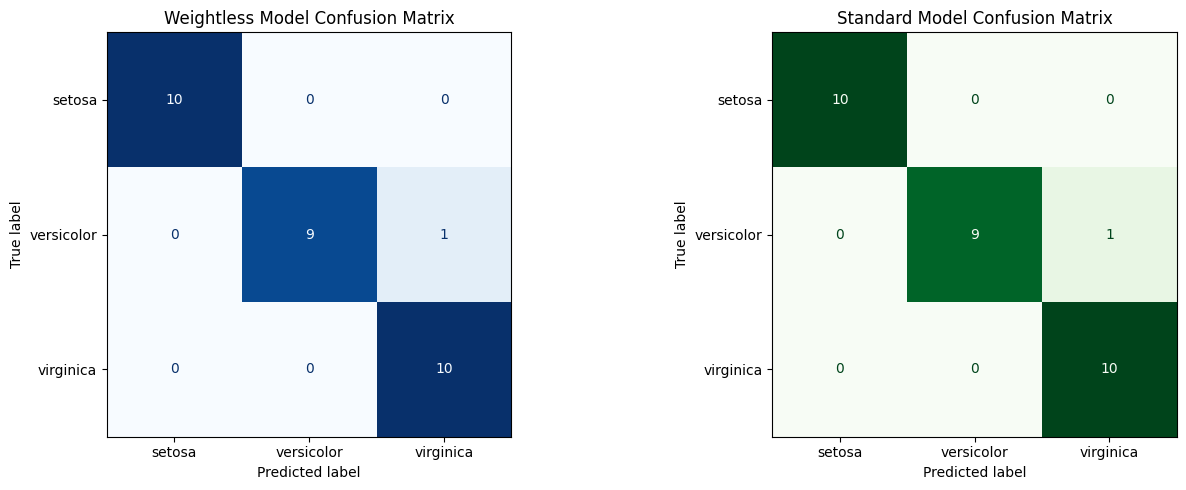

In [ ]:
plot_wine_confusion(weightless_iris, standard_iris, X_test_i, y_test_i, iris.target_names)

## 16. Testing on Olivetti Faces (64x64 images)

We now scale up to 64x64 grayscale images. With 4,096 input features, the 'adapter' layers become larger, and the target stack has to process much more complex spatial information.

### 16. Testing on Olivetti Faces (64x64 images)

Finally, we scale up to 64x64 grayscale images (4,096 features). This is the most demanding task for our 256x256 target stack, requiring the hypernetwork to represent much finer spatial detail.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces

# Load Olivetti data
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
X_ol, y_ol = olivetti.data, olivetti.target

# Standardize
X_ol = (X_ol - X_ol.mean()) / X_ol.std()

X_train_ol, X_test_ol, y_train_ol, y_test_ol = train_test_split(
    X_ol, y_ol, test_size=0.2, random_state=42, stratify=y_ol
)

X_train_ol = torch.tensor(X_train_ol, device=device)
X_test_ol = torch.tensor(X_test_ol, device=device)
y_train_ol = torch.tensor(y_train_ol, device=device)
y_test_ol = torch.tensor(y_test_ol, device=device)

OL_IN_DIM = X_ol.shape[1] # 4096
OL_CLASSES = 40

# Re-initialize models for Olivetti
weightless_ol = WeightlessTargetNetwork(OL_IN_DIM, HID, N_LAYERS, OL_CLASSES).to(device)
standard_ol = StandardTargetNetwork(OL_IN_DIM, HID, N_LAYERS, OL_CLASSES).to(device)

print(f"Training Weightless Model on Olivetti (Input Dim: {OL_IN_DIM})...")
train_model(weightless_ol, X_train_ol, y_train_ol, epochs=150)

print("Training Standard Model on Olivetti...")
train_model(standard_ol, X_train_ol, y_train_ol, epochs=150)

# Evaluation
weightless_ol.eval()
standard_ol.eval()
with torch.no_grad():
    acc_w_ol = (weightless_ol(X_test_ol).argmax(1) == y_test_ol).float().mean().item()
    acc_s_ol = (standard_ol(X_test_ol).argmax(1) == y_test_ol).float().mean().item()

print(f"\nResults on Olivetti Task:")
print(f"Weightless Accuracy: {acc_w_ol:.4f}")
print(f"Standard Accuracy:   {acc_s_ol:.4f}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Training Weightless Model on Olivetti (Input Dim: 4096)...
Training Standard Model on Olivetti...

Results on Olivetti Task:
Weightless Accuracy: 0.9750
Standard Accuracy:   0.9875


We re-run the visualization utility for the Olivetti dataset, ensuring the labels dynamically reflect the Subject IDs (0-39) for each individual.

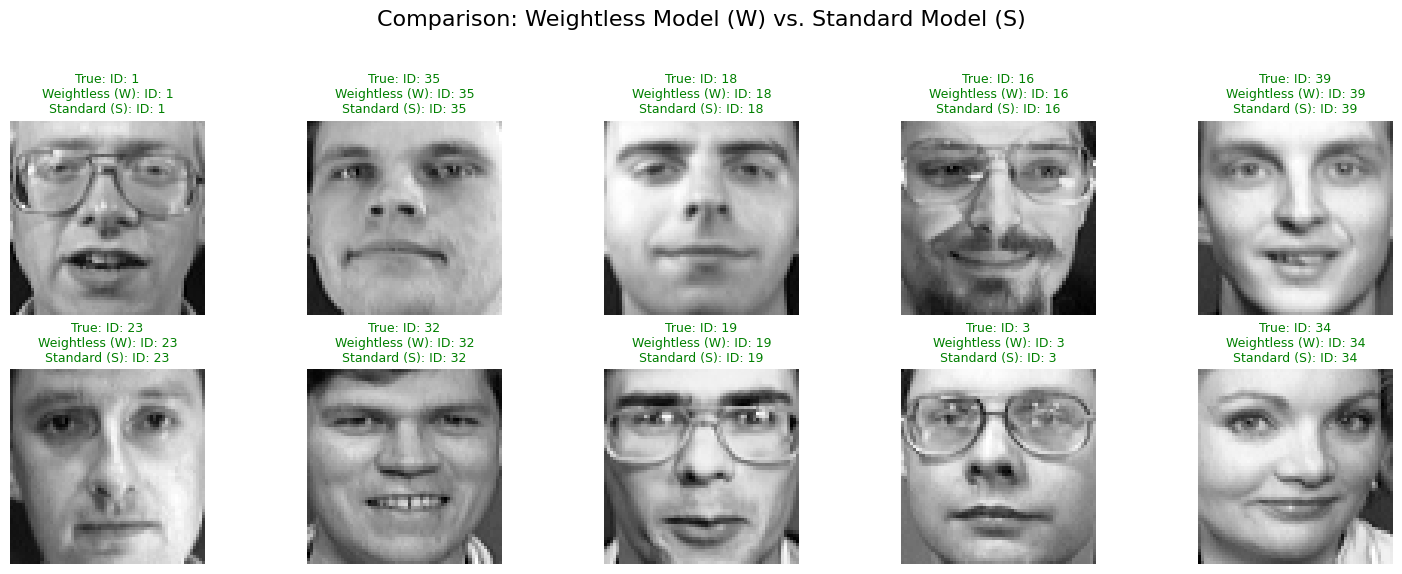

In [ ]:
# Re-run visualization for Olivetti with corrected dynamic labels
plot_predictions(weightless_ol, standard_ol, X_test_ol, y_test_ol, 64, 64, target_names=None, n_images=10)

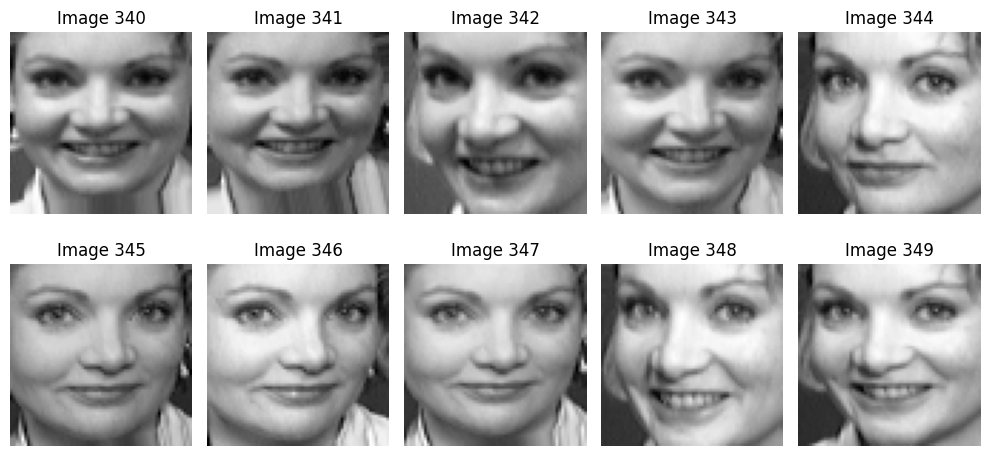

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# 1. Load the Olivetti Faces dataset
# The dataset has 400 faces of 40 different people (10 images per person)
faces_data = fetch_olivetti_faces()
images = faces_data.images
target = faces_data.target

# 2. Find all images belonging to Subject ID 18
# This will find the 10 images with label 18 (indices 180 to 189)
subject_id = 34
subject_indices = [i for i, label in enumerate(target) if label == subject_id]

# 3. Create a 2x5 grid plot to show all 10 faces of this person
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i, img_idx in enumerate(subject_indices):
    axes[i].imshow(images[img_idx], cmap='gray')
    axes[i].set_title(f"Image {img_idx}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 17. Final Summary of Results

Based on our experiments, here are the key performance metrics comparing the **Weightless (Hypernetwork)** model against the **Standard** baseline:

### Parameter Compression
* **Standard Hidden Stack (10x 256x256):** 655,360 parameters
* **Hypernetwork Generator:** 10,001 parameters
* **Achieved Compression Ratio:** ~65.5x

### Accuracy Comparison
| Task | Weightless Accuracy | Standard Accuracy |
| :--- | :--- | :--- |
| **Digits (8x8)** | 96.94% | 97.78% |
| **LFW Faces (Binary)** | 86.94% | 91.90% |
| **Wine (Tabular)** | 91.67% | 100.00% |
| **Iris (Low-Dim)** | 96.67% | 96.67% |
| **Olivetti (64x64)** | 97.50% | 98.75% |

### Compute Trade-off
* **Weightless Inference Time:** ~13.37 ms
* **Standard Inference Time:** ~0.83 ms
* **Result:** The Weightless model is approximately **16.2x slower** per forward pass due to the on-the-fly weight generation process.

### Conclusion
The POC proves that we can successfully replace massive weight storage with a tiny coordinate-based generator while maintaining high accuracy. However, as predicted, this introduces a significant compute bottleneck that would require specialized optimization or caching to be viable at production scales.